In [106]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [107]:
np.random.seed(42)

In [108]:
# ---------------------------------------------------------
# Generisanje gradova i težinskog grafa
# ---------------------------------------------------------
num_cities = 60
start_city = 5
target_city = 52

cities = np.random.rand(num_cities, 2) * 100

In [109]:
# Graf je potpuno povezan (svaki grad ima vezu sa svakim), ali
# težina ivice NIJE euklidska udaljenost, nego nezavisna slučajna
# vrijednost (npr. cijena puta) - inače bi po nejednakosti trougla
# direktna ivica 3->18 uvijek bila najkraća i zadatak bi bio trivijalan.
adj = np.ones((num_cities, num_cities), dtype=bool)
np.fill_diagonal(adj, False)

weight = np.random.randint(1, 5000, size=(num_cities, num_cities)).astype(float)
weight = (weight + weight.T) / 2  # simetrično
np.fill_diagonal(weight, np.inf)

In [110]:
# Direktna ivica start->cilj je namjerno skupa (npr. nema direktnog leta,
# ili je to skup autoput) - inače često ispadne da je baš ta ivica
# slučajno najjeftinija i zadatak postane trivijalan (jedan skok).
weight[start_city][target_city] = 20000
weight[target_city][start_city] = 20000

In [111]:
# provjera povezanosti grafa (da put od 3 do 18 uopšte postoji)
G_check = nx.Graph()
for i in range(num_cities):
    for j in range(num_cities):
        if adj[i][j]:
            G_check.add_edge(i, j, weight=weight[i][j])
assert nx.has_path(G_check, start_city, target_city), "Graf nije povezan, promijeni seed ili k_neighbors"

In [112]:
# ---------------------------------------------------------
# Heuristika (računa se samo jednom, prije glavne petlje)
# ---------------------------------------------------------
heuristic = np.zeros((num_cities, num_cities))
for i in range(num_cities):
    for j in range(num_cities):
        if adj[i][j]:
            heuristic[i][j] = 1 / weight[i][j]

In [113]:
# ---------------------------------------------------------
# Feromoni - inicijalno 1 samo na postojećim ivicama
# ---------------------------------------------------------
pheromone = np.where(adj, 1.0, 0.0)

In [114]:
# ---------------------------------------------------------
# Ponašanje jednog mrava: gradi put od start_city do target_city
# Vraća None ako mrav upadne u slijepu ulicu (nema neposjećenih
# suseda, a cilj još nije dostignut)
# ---------------------------------------------------------
def build_path(pheromone, heuristic, adj, alpha, beta, start, target, max_steps):
    path = [start]
    visited = {start}
    current = start

    while current != target:
        neighbors = [j for j in range(num_cities) if adj[current][j] and j not in visited]

        if not neighbors:
            return None  # slijepa ulica, mrav odustaje

        probs = np.array([
            (pheromone[current][j] ** alpha) * (heuristic[current][j] ** beta)
            for j in neighbors
        ])

        total = probs.sum()
        if total == 0:
            probs[:] = 1 / len(neighbors)
        else:
            probs /= total

        next_city = np.random.choice(neighbors, p=probs)
        path.append(next_city)
        visited.add(next_city)
        current = next_city

        if len(path) > max_steps:
            return None  # predugo luta, odustaje

    return path

In [115]:
def path_length(path, weight):
    return sum(weight[path[i]][path[i + 1]] for i in range(len(path) - 1))

In [116]:
# ---------------------------------------------------------
# Parametri
# ---------------------------------------------------------
num_ants = 10
num_iterations = 30
alpha = 1.0
beta = 2.0
rho = 0.3
Q = 10
max_steps = num_cities  # sigurnosna granica da mrav ne luta unedogled

best_path = None
best_length = float("inf")

In [117]:
# ---------------------------------------------------------
# Glavna petlja
# ---------------------------------------------------------
for iteration in range(num_iterations):
    paths = []
    lengths = []

    for ant in range(num_ants):
        path = build_path(pheromone, heuristic, adj, alpha, beta, start_city, target_city, max_steps)

        if path is None:
            continue  # neuspješan mrav, ne učestvuje u ažuriranju

        length = path_length(path, weight)
        paths.append(path)
        lengths.append(length)

        if length < best_length:
            best_length = length
            best_path = path

    # isparavanje feromona (samo na postojećim ivicama)
    pheromone *= (1 - rho)

    # ažuriranje feromona - samo na ivicama uspješnih puteva
    for path, length in zip(paths, lengths):
        for i in range(len(path) - 1):
            a, b = path[i], path[i + 1]
            pheromone[a][b] += Q / length
            pheromone[b][a] += Q / length

    success_rate = len(paths) / num_ants
    print(f"Iteracija {iteration + 1}: najbolja dužina = {best_length:.2f}  "
          f"(uspješnih mrava: {len(paths)}/{num_ants})")


print("\nNajbolji put pronađen (ACO):", best_path)
print("Dužina:", round(best_length, 2))

Iteracija 1: najbolja dužina = 8924.50  (uspješnih mrava: 10/10)
Iteracija 2: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 3: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 4: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 5: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 6: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 7: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 8: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 9: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 10: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 11: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 12: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 13: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 14: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 15: najbolja dužina = 1463.50  (uspješnih mrava: 10/10)
Iteracija 16: najbo

In [118]:
# ---------------------------------------------------------
# Provjera tačnosti - Dijkstra (networkx)
# ---------------------------------------------------------
exact_path = nx.shortest_path(G_check, start_city, target_city, weight="weight")
exact_length = nx.shortest_path_length(G_check, start_city, target_city, weight="weight")

print("\nTAČNO najkraći put (Dijkstra):", exact_path)
print("Dužina:", round(exact_length, 2))


TAČNO najkraći put (Dijkstra): [5, 25, 52]
Dužina: 1463.5


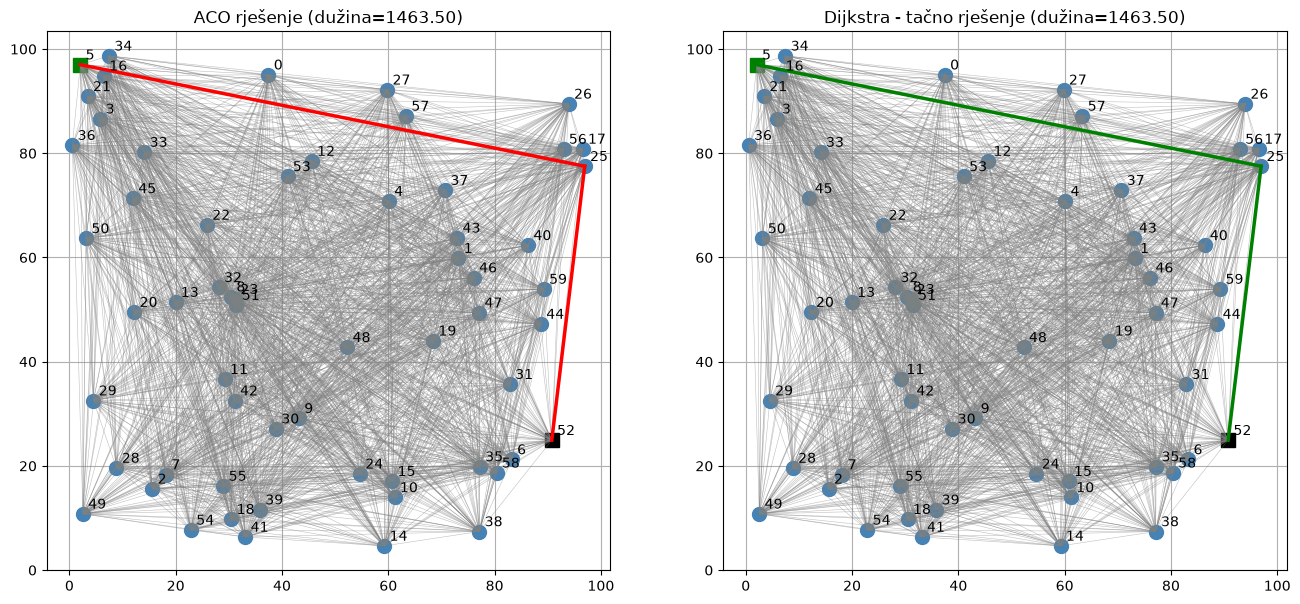

In [119]:
# ---------------------------------------------------------
# Vizuelizacija
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, path, title, color in [
    (axes[0], best_path, f"ACO rješenje (dužina={best_length:.2f})", "r"),
    (axes[1], exact_path, f"Dijkstra - tačno rješenje (dužina={exact_length:.2f})", "g"),
]:
    for i in range(num_cities):
        marker = "o"
        c = "steelblue"
        if i == start_city:
            c, marker = "green", "s"
        elif i == target_city:
            c, marker = "black", "s"
        ax.plot(cities[i, 0], cities[i, 1], marker, color=c, markersize=10)
        ax.text(cities[i, 0] + 1, cities[i, 1] + 1, str(i), fontsize=10)

    for i in range(num_cities):
        for j in range(i + 1, num_cities):
            if adj[i][j]:
                ax.plot([cities[i, 0], cities[j, 0]], [cities[i, 1], cities[j, 1]],
                        "gray", linewidth=0.4, alpha=0.5)

    for i in range(len(path) - 1):
        a, b = path[i], path[i + 1]
        ax.plot([cities[a, 0], cities[b, 0]], [cities[a, 1], cities[b, 1]],
                color=color, linewidth=2.5)

    ax.set_title(title)
    ax.grid(True)

In [120]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>